DO NOT MODIFY THE NEXT CELL (PENALTY of 0.5 POINTS)

In [1]:
import numpy as np

np.random.seed(0)
n_samples = 100
X = np.linspace(-3, 3, n_samples).reshape(-1, 1)

def true_function(x):
    return 0.5 * x**4 - x**3 - x**2 + x + 2

y_true = true_function(X)
noise = np.random.normal(0, 5, size=y_true.shape)
y = y_true + noise

# DO NOT MODIFY THIS CODE CELL (PENALTY of 0.5 POINTS)

Place below your code

Degree  1 | Train MSE =  132.213 | Test MSE =  226.858
Degree  2 | Train MSE =   44.543 | Test MSE =   73.807
Degree  3 | Train MSE =   29.134 | Test MSE =   48.584
Degree  4 | Train MSE =   21.634 | Test MSE =   23.566
Degree  5 | Train MSE =   21.035 | Test MSE =   24.601
Degree  6 | Train MSE =   21.026 | Test MSE =   24.611
Degree  7 | Train MSE =   20.950 | Test MSE =   26.192
Degree  8 | Train MSE =   20.949 | Test MSE =   26.189
Degree  9 | Train MSE =   20.940 | Test MSE =   26.268
Degree 10 | Train MSE =   20.939 | Test MSE =   26.430


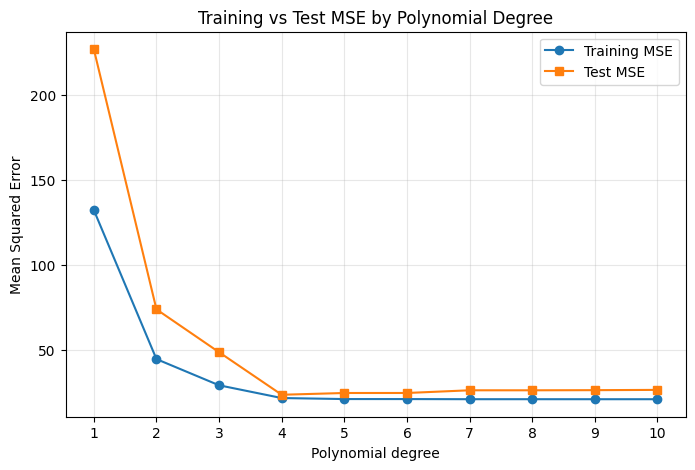

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Single train / test split
# ---------------------------------------------------------
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# ---------------------------------------------------------
# 2. For each polynomial degree 1..10: fit and record BOTH MSEs
# ---------------------------------------------------------
degree_list = range(1, 11)
train_mse_list = []
test_mse_list = []

for d in degree_list:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)        # transform only (use train's fit)

    reg = LinearRegression().fit(X_train_poly, y_train)

    train_mse = mean_squared_error(y_train, reg.predict(X_train_poly))
    test_mse  = mean_squared_error(y_test,  reg.predict(X_test_poly))

    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

    print(f"Degree {d:2d} | Train MSE = {train_mse:8.3f} | Test MSE = {test_mse:8.3f}")

# ---------------------------------------------------------
# 3. Plot training vs test MSE as a function of degree
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(list(degree_list), train_mse_list, marker='o', label='Training MSE')
plt.plot(list(degree_list), test_mse_list,  marker='s', label='Test MSE')
plt.xlabel('Polynomial degree')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Test MSE by Polynomial Degree')
plt.xticks(list(degree_list))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()